<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/Exercise8_RegressionAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_ccpr


In [2]:
# Load dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip',
    sep=";"
)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## Preprocessing Stage:
**Step 1: Check if any variable requires transformation and apply the appropriate transformation.**

**AI Prompt used:**
*check visually if the following continuous environmental variables require transformation: Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul. Plot histograms, and Q-Q plots for all variables*


Distribution of Environmental Variables


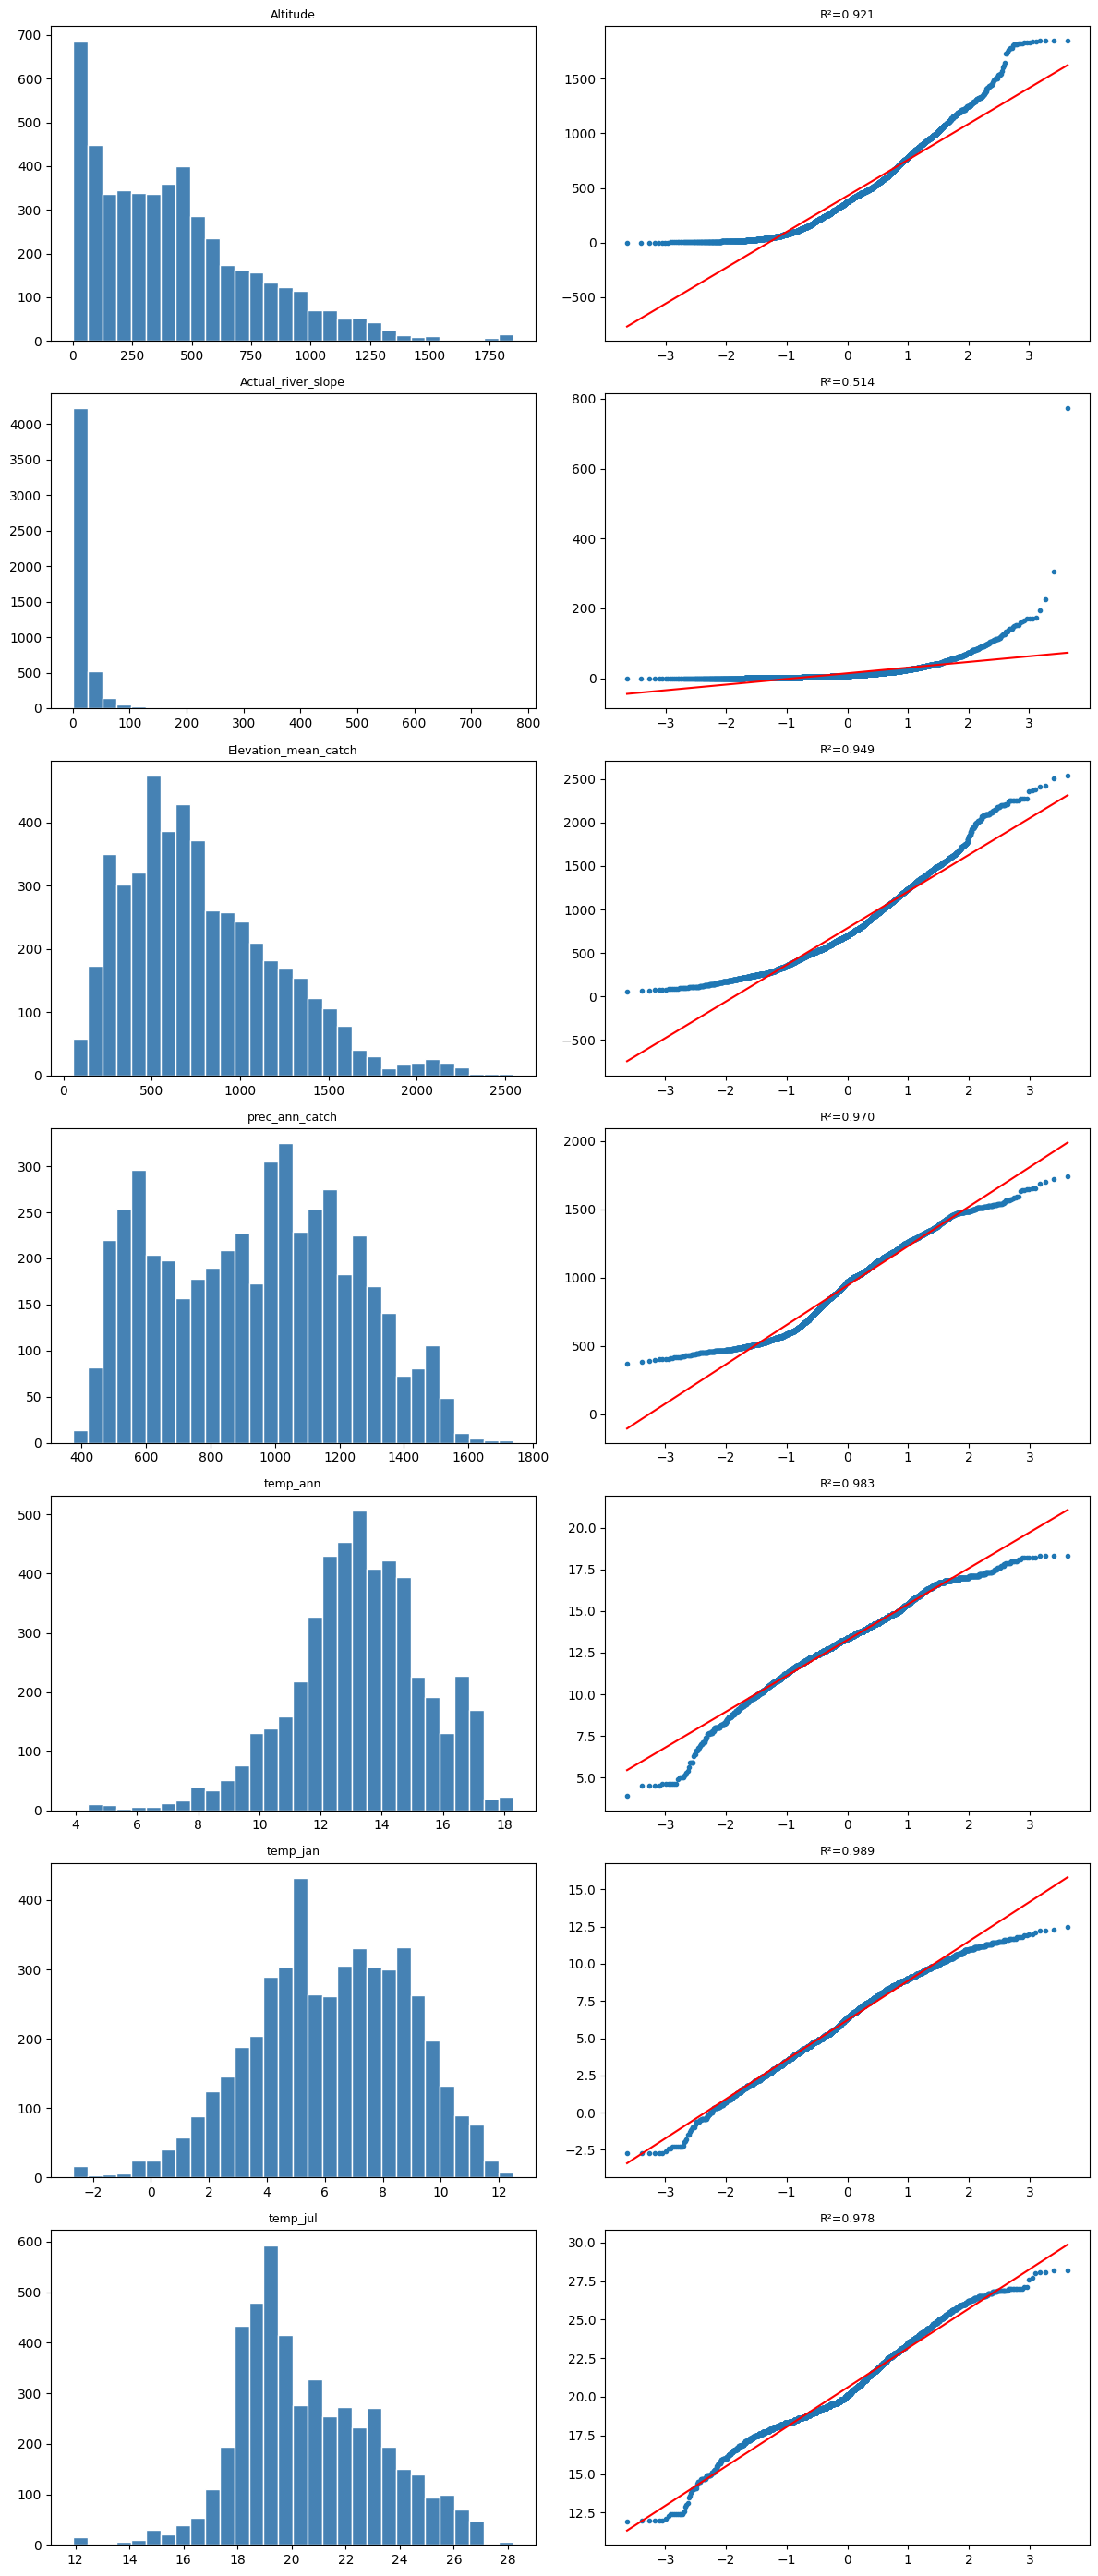

In [10]:
#check if any of Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul
# variables requires to be transformed
plt.style.use('default')

env_vars = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

print("\n" + "="*60)
print("Distribution of Environmental Variables")
print("="*60)

fig, axes = plt.subplots(len(env_vars), 2, figsize=(12, 4 * len(env_vars)))
axes[0, 0].set_title('Histogram')
axes[0, 1].set_title('Q-Q Plot')

for i, var in enumerate(env_vars):
    col = df[var].dropna()

    # Histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(col, bins=30, color='steelblue', edgecolor='white')
    ax_hist.set_title(f'{var}', fontsize=9)


    # Q-Q plot
    ax_qq = axes[i, 1]
    (osm, osr), (slope, intercept, r) = sts.probplot(col, dist="norm")
    ax_qq.plot(osm, osr, 'o', markersize=3)
    ax_qq.plot(osm, slope * np.array(osm) + intercept, 'r-')
    ax_qq.set_title(f'R²={r**2:.3f}', fontsize=9)

plt.tight_layout()
plt.show()

From the visual inspection of the plots: Altitude, Actual_river_slope, Elevation_mean_catch, and prec_ann_catch show clear right-skewed distributions. Their Q-Q plots deviate significantly from the red line, indicating non-normal behavior. In contrast, temp_ann, temp_jan, and temp_jul appear more symmetric, with slight deviaitons observed on their Q-Q plots. Therefore,data transformation for Altitude, Actual_river_slope, Elevation_mean_catch, and prec_ann_catch would be necessary.

**AI Prompt used:**
* Apply log10(x+1) transformation to skewed variables and replot to check the new distributions.*

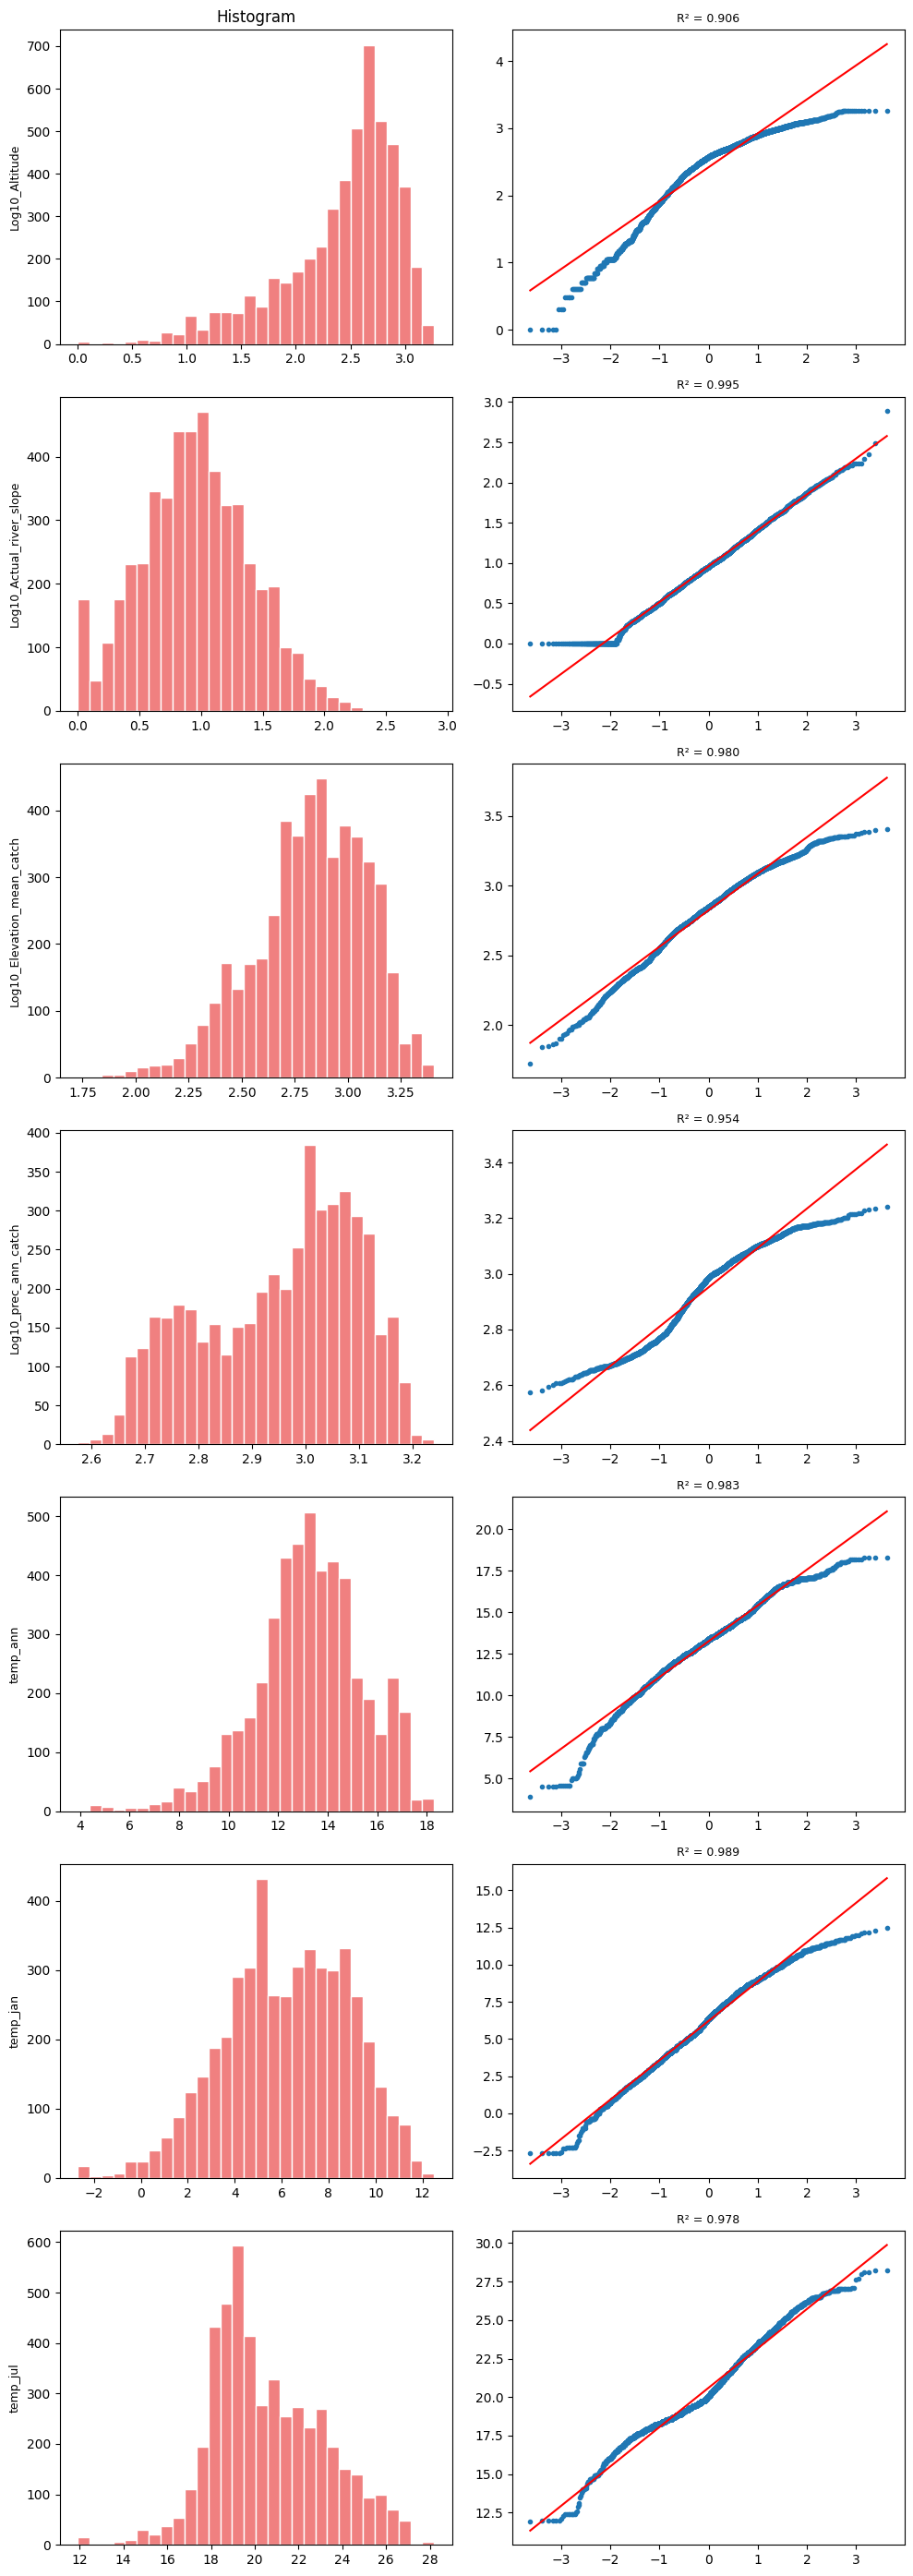

Predictors to use:
  Log10_Altitude
  Log10_Actual_river_slope
  Log10_Elevation_mean_catch
  Log10_prec_ann_catch
  temp_ann
  temp_jan
  temp_jul


In [16]:
# ── Apply log10 transformations ──────────────────────────────────────
skewed_vars = ['Altitude', 'Actual_river_slope',
               'Elevation_mean_catch', 'prec_ann_catch']

no_transf_vars = ['temp_ann', 'temp_jan', 'temp_jul']

# Create transformed variables
for var in skewed_vars:
    df[f'Log10_{var}'] = np.log10(df[var] + 1)

# Final predictor names
predictors = [f'Log10_{v}' for v in skewed_vars] + no_transf_vars

# Variables to visualize
transformed_env_vars_log10 = predictors

# Create subplot figure
fig, axes = plt.subplots(len(transformed_env_vars_log10), 2,
                         figsize=(10, 4 * len(transformed_env_vars_log10)))

# Fix issue when only one variable exists
if len(transformed_env_vars_log10) == 1:
    axes = np.expand_dims(axes, axis=0)

# Column titles
axes[0, 0].set_title('Histogram')
axes[0, 1].set_title('Q-Q Plot')

# Plot each variable
for i, var in enumerate(transformed_env_vars_log10):

    col = df[var].dropna()

    # Histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(col, bins=30,
                 color='lightcoral',
                 edgecolor='white')

    ax_hist.set_ylabel(var, fontsize=9)

    # Q-Q plot
    ax_qq = axes[i, 1]

    (osm, osr), (slope, intercept, r) = sts.probplot(col, dist="norm")

    ax_qq.plot(osm, osr, 'o', markersize=3)
    ax_qq.plot(osm,
               slope * np.array(osm) + intercept,
               'r-')

    ax_qq.set_title(f'R² = {r**2:.3f}', fontsize=9)

plt.tight_layout()
plt.show()

# Print predictors
print("Predictors to use:")
for p in predictors:
    print(f"  {p}")

**Step 2: Create a species richness column by summing all species presence/absence columns (starting from Abramis brama) across each row.**

**AI Prompt Used:**
*Create a species richness column by summing all species presence/absence columns starting from 'Abramis brama' across each row. Exclude any log10 transformed columns or previously created columns from the sum.*

In [14]:
# Create a column with the total number of species present (the species richness) in each sampling site
first_species = 'Abramis brama'
species_start_idx = df.columns.get_loc(first_species)

# Select only true species columns (exclude Log10_ transformations and species_richness)
species_cols = [col for col in df.columns[species_start_idx:]
                if col != 'species_richness' and not col.startswith('Log10_')]
df['species_richness'] = df[species_cols].sum(axis=1)
# Summary
print('\nDescriptive statistics for species_richness:')
print(df['species_richness'].describe())

# Show result
print('\nFirst 10 rows:')
print(df[['Site_code', 'species_richness']].head(10))




Descriptive statistics for species_richness:
count    5011.000000
mean        3.508481
std         2.879080
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        29.000000
Name: species_richness, dtype: float64

First 10 rows:
    Site_code  species_richness
0  ES_01_0002                 1
1  ES_02_0001                 1
2  ES_02_0002                 1
3  ES_02_0003                 2
4  ES_02_0004                 2
5  ES_02_0005                 4
6  ES_02_0006                 4
7  ES_02_0007                 6
8  ES_02_0008                 4
9  ES_02_0010                 1



##Question 1: A simple linear regression relating the species richness with each one of the continuous environmental variables in the dataset: Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul. Compute the regression coefficient estimates, the r-square and the F-statistics. You may plot the fitted model.

**AI Prompt Used:**
*Run a simple linear regression of species richness against each of the following transformed environmental variables: Log10_Altitude, Log10_Actual_river_slope, Log10_Elevation_mean_catch, Log10_prec_ann_catch, temp_ann, temp_jan, temp_jul. For each regression report the coefficient, intercept, R² and F-statistic. Plot all fitted models in a single grid*


Simple Linear Regression


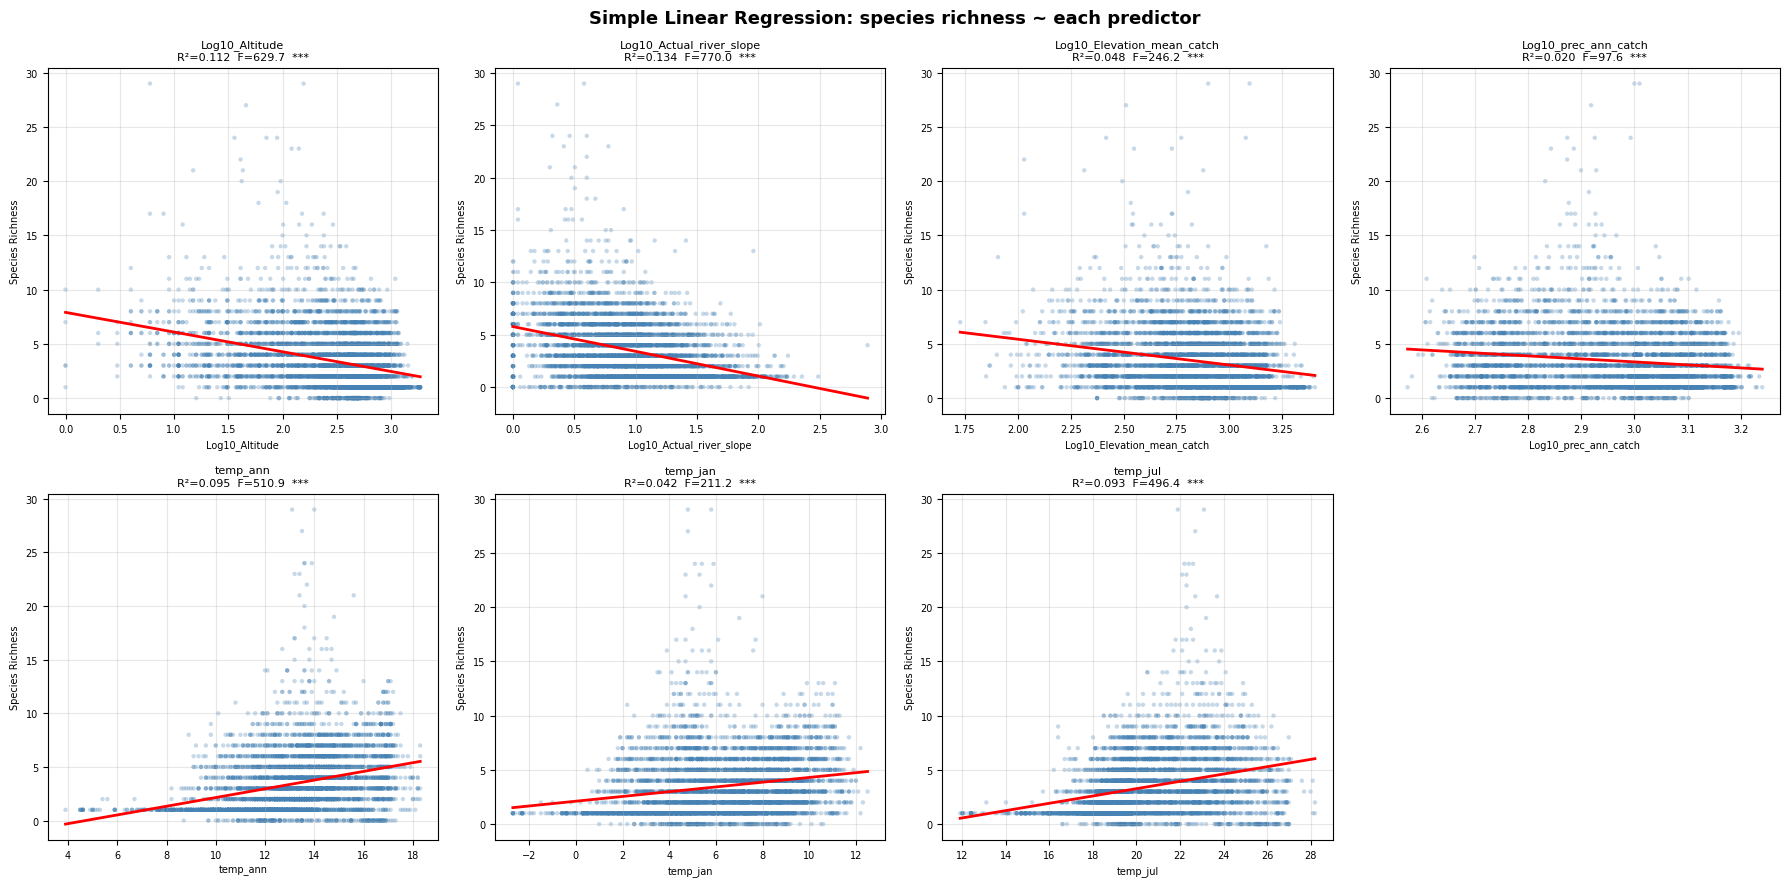


Simple Linear Regression Summary:
                 Predictor  Coefficient (slope)  Intercept     R²  F-statistic  p-value
            Log10_Altitude              -1.8166     7.9043 0.1117     629.6609      0.0
  Log10_Actual_river_slope              -2.3645     5.7779 0.1341     769.9924      0.0
Log10_Elevation_mean_catch              -2.3744    10.1747 0.0484     246.2499      0.0
      Log10_prec_ann_catch              -2.7708    11.6489 0.0198      97.5649      0.0
                  temp_ann               0.4060    -1.9130 0.0955     510.8913      0.0
                  temp_jan               0.2192     2.1093 0.0418     211.1585      0.0
                  temp_jul               0.3370    -3.4728 0.0930     496.4423      0.0


In [20]:
# Simple linear regression (one per predictor)

print("\n" + "="*60)
print("Simple Linear Regression")
print("="*60)

# Summary table
results = []

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('Simple Linear Regression: species richness ~ each predictor',
             fontsize=13, fontweight='bold')

for i, pred in enumerate(predictors):
    # Drop NAs
    data = df[[pred, 'species_richness']].dropna()
    X = data[pred].values
    y = data['species_richness'].values

    # Scipy regression (gives F and p directly)
    slope, intercept, r, p, se = sts.linregress(X, y)
    r2     = r**2
    n      = len(X)
    k      = 1  # number of predictors
    F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))

    results.append({
        'Predictor': pred,
        'Coefficient (slope)': round(slope, 4),
        'Intercept': round(intercept, 4),
        'R²': round(r2, 4),
        'F-statistic': round(F_stat, 4),
        'p-value': round(p, 6)
    })

    # Plot fitted model
    ax = axes[i]
    ax.scatter(X, y, alpha=0.3, s=10, color='steelblue', edgecolors='none')
    x_line = np.linspace(X.min(), X.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(f'{pred}\nR²={r2:.3f}  F={F_stat:.1f}  {sig}', fontsize=8)
    ax.set_xlabel(pred, fontsize=7)
    ax.set_ylabel('Species Richness', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Print summary table
results_df = pd.DataFrame(results)
print("\nSimple Linear Regression Summary:")
print(results_df.to_string(index=False))

In the above, seven simple linear regressions were run, each relating species richness to one environmental predictor. All predictors were statistically significant (p < 0.001). Variables Log10_Altitude, Log10_Actual_river_slope, Log10_Elevation_mean_catch, and Log10_prec_ann_catch all showed negative relationships with species richness,  meaning that higher altitude, steeper slopes, higher catchment elevation and higher precipitation are associated with fewer species. The temperature variables (temp_ann, temp_jan, temp_jul) all showed positive relationships, indicating that warmer sites tend to have more species. However, the R² values across all seven models were relatively low (ranging from 0.020 to 0.134), indicating that each variable alone explains only a small portion of the variation in species richness.

##Question 2: Now try to run a multiple linear regression with the same data and check the differences between the previous univariate regression coefficients and the new coefficients. Plot the partial dependence plots to compare responses with the previous single effects.

**AI Prompt Used:**
*Run a multiple linear regression using all seven predictors from Question 1 to explain species richness. Use statsmodels OLS to get the full model summary including R², F-statistic and coefficients. Compare the coefficients between the simple and multiple regression models in a table and plot partial dependence plots for all predictors. Additionally, plot Component-Component Plus Residual (CCPR) plots for all predictors using statsmodels plot_ccpr to diagnostically assess the quality of each partial linear relationship and check for heteroscedasticity or non-linearity.*


Multiple Linear Regression
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     233.7
Date:                Thu, 14 May 2026   Prob (F-statistic):          4.61e-300
Time:                        13:30:43   Log-Likelihood:                -11190.
No. Observations:                4819   AIC:                         2.240e+04
Df Residuals:                    4811   BIC:                         2.245e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

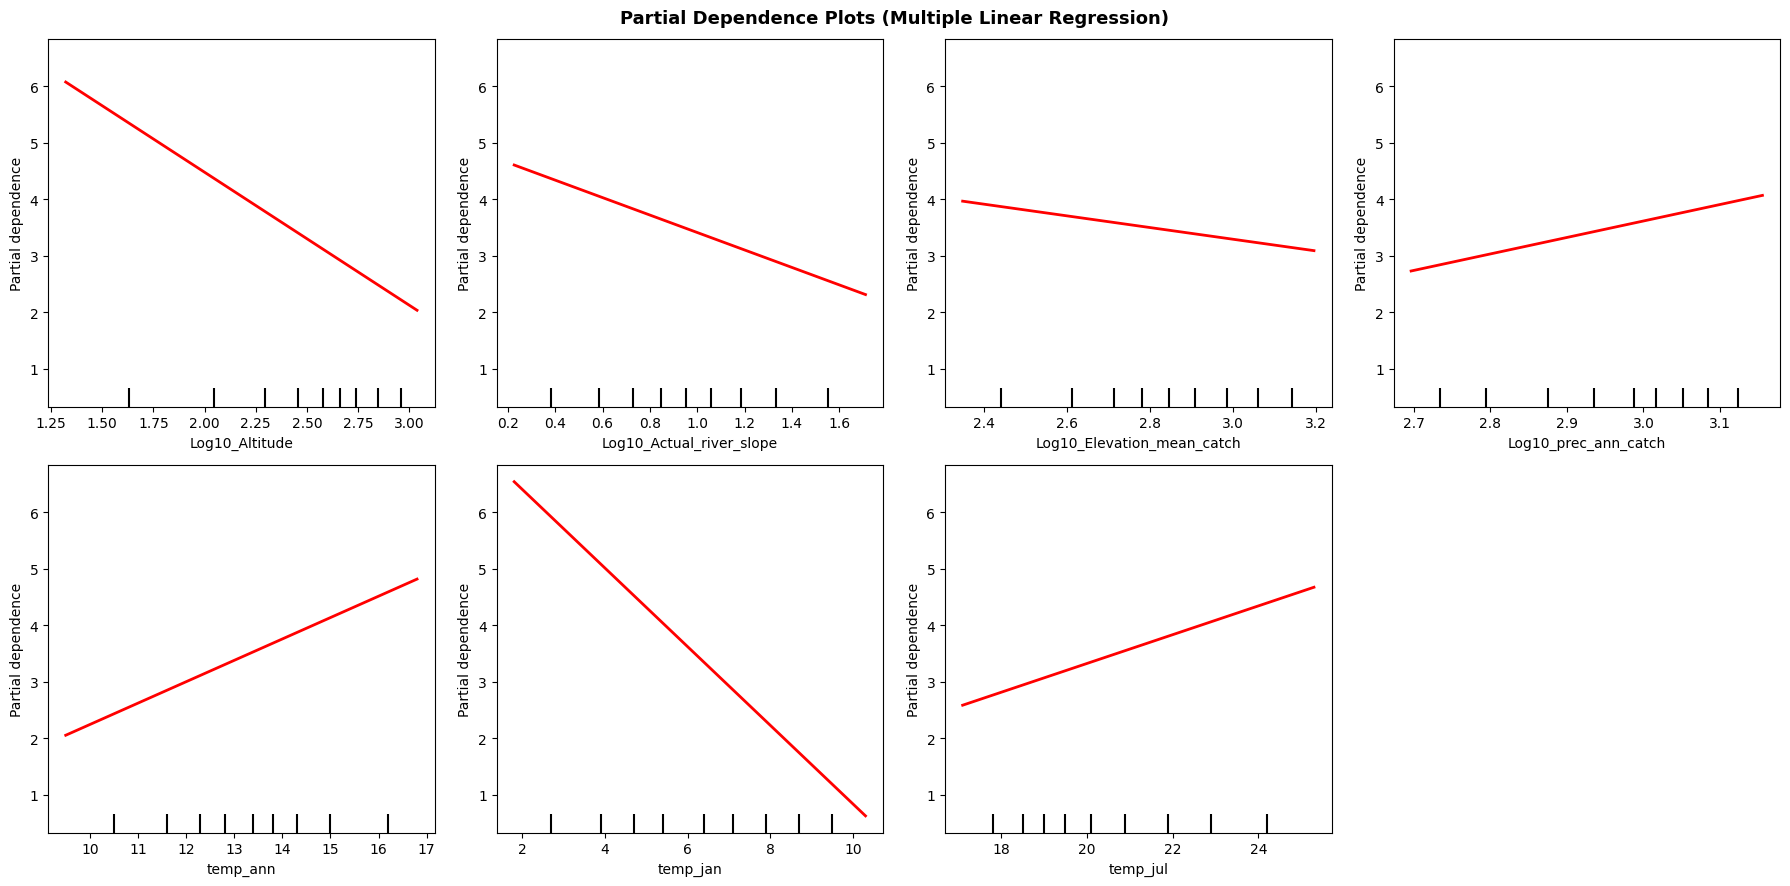

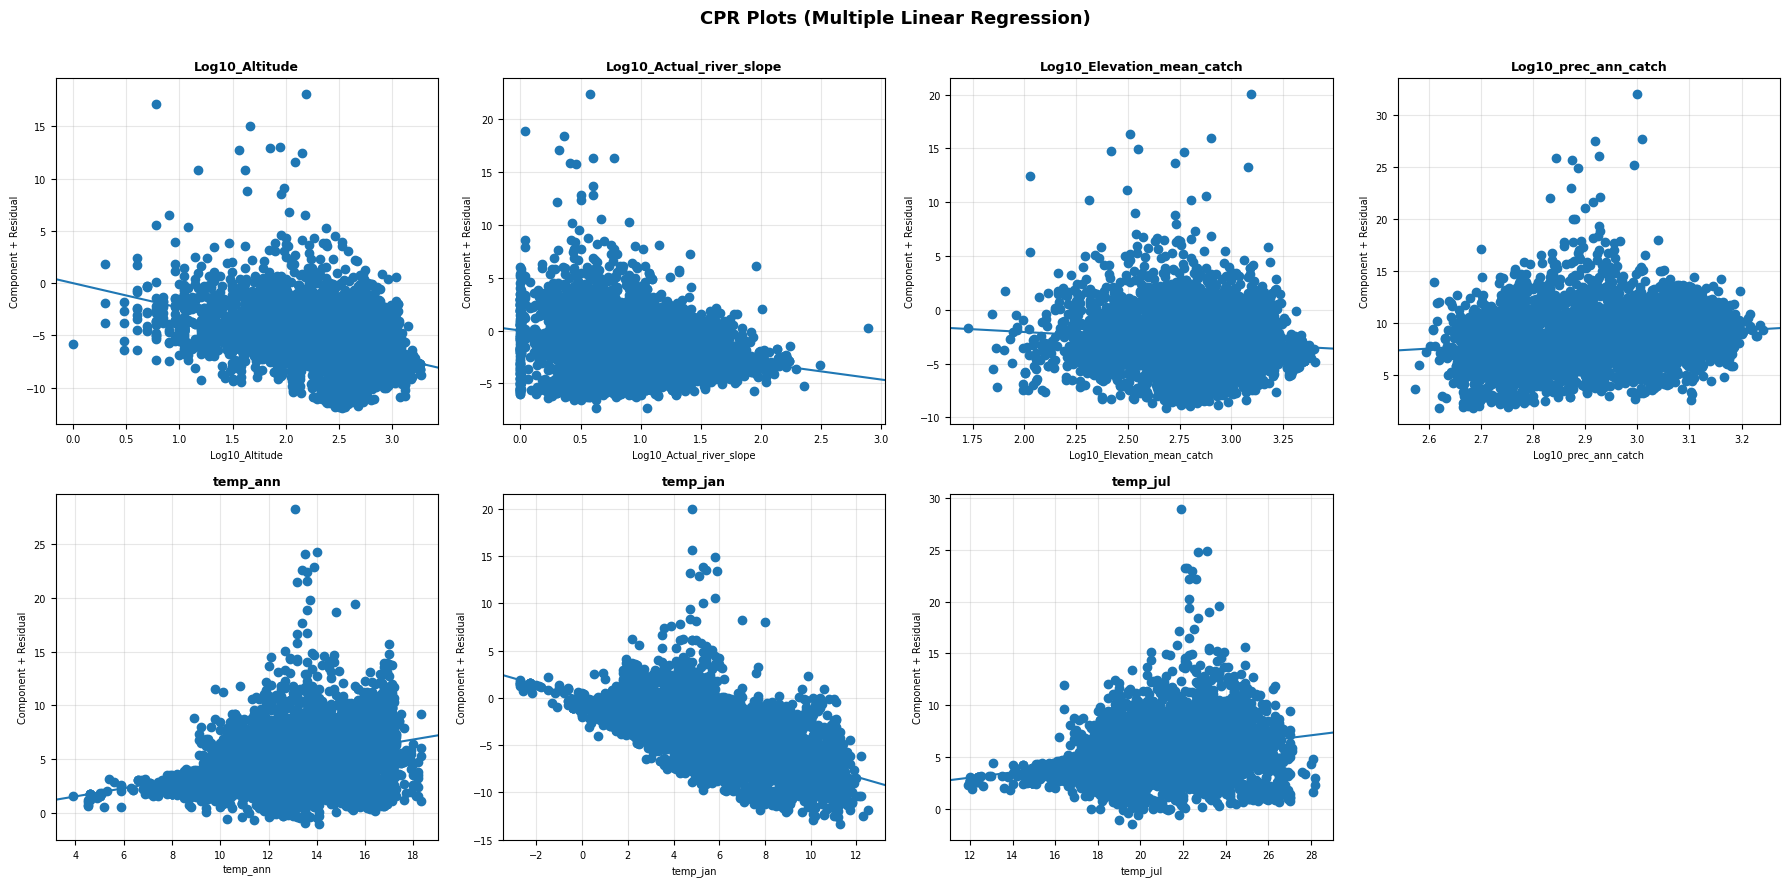

In [32]:

print("\n" + "="*60)
print("Multiple Linear Regression")
print("="*60)

# Prepare data — drop NAs across all predictors
model_data = df[predictors + ['species_richness']].dropna()
X_multi = model_data[predictors]
y_multi = model_data['species_richness']

# ── Statsmodels for coefficients, R², F-statistic ────────────
X_sm = sm.add_constant(X_multi)
mlr_model = sm.OLS(y_multi, X_sm).fit()
print(mlr_model.summary())

# ── Compare simple vs multiple regression coefficients ───────
print("\nCoefficient comparison: Simple vs Multiple regression:")
print(f"{'Predictor':<30} {'Simple coef':>12} {'Multiple coef':>14} {'Change':>10}")
print("-" * 70)
for row in results:
    pred  = row['Predictor']
    s_coef = row['Coefficient (slope)']
    m_coef = mlr_model.params.get(pred, np.nan)
    change = m_coef - s_coef
    print(f"{pred:<30} {s_coef:>12.4f} {m_coef:>14.4f} {change:>10.4f}")

# ── Partial dependence plots ──────────────────────────────────
# Using sklearn for partial dependence
from sklearn.linear_model import LinearRegression as SKLinReg

sk_model = SKLinReg()
sk_model.fit(X_multi, y_multi)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('Partial Dependence Plots (Multiple Linear Regression)',
             fontsize=13, fontweight='bold')

PartialDependenceDisplay.from_estimator(
    sk_model,
    X_multi,
    features=list(range(len(predictors))),
    feature_names=predictors,
    ax=axes[:len(predictors)],
    line_kw={'color': 'red', 'linewidth': 2}
)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


# ── CCPR Plots (Component-Component Plus Residual) ────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('CPR Plots (Multiple Linear Regression)\n',
             fontsize=13, fontweight='bold')

for i, pred in enumerate(predictors):
    plot_ccpr(mlr_model, pred, ax=axes[i])
    axes[i].set_title(pred, fontsize=9, fontweight='bold')
    axes[i].set_xlabel(pred, fontsize=7)
    axes[i].set_ylabel('Component + Residual', fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

The overall R² improved to 0.254 when all predictors were combined into a single multiple regression model,  meaning the model together explains 25.4% of the variation in species richness which is considerably more than any single predictor alone. The F-statistic of 233.7 (p < 0.001) confirms the model is highly significant overall.

However, comparing the coefficients between the simple and multiple regressions reveals important changes. The most striking shift is in Log10_prec_ann_catch that completely reversed direction, coefficient changed from -2.77 in the simple regression to +2.92 in the multiple regression. This is a classic sign of multicollinearity: when predictors are correlated with each other, their individual coefficients in the multiple model become unreliable and can change dramatically or even switch sign. Similarly, temp_jan changed from positive (+0.22) to strongly negative (-0.70), suggesting its effect is being confounded by the other temperature variables included in the same model.

The partial dependence plots confirm the direction of each variable's effect when all others are held constant — altitude, river slope, elevation and catchment all show negative partial effects, while temp_ann and temp_jul show positive partial effects. Notably, temp_jan shows a strong negative partial effect in the multiple model, contrasting with its positive simple regression coefficient, further highlighting the distortion caused by multicollinearity.

As an additional diagnostic, CCPR plots were examined to assess the quality of each partial linear relationship. While the fitted lines are consistent with the partial dependence plots in terms of direction, the CCPR plots reveal high residual scatter around most predictors and fan-shaped patterns for the temperature variables, suggesting heteroscedasticity and possible non-linearity. This indicates that although the multiple regression model is statistically significant, the linear assumption may be too simplistic for some predictors.

## Question 3: Check the multicolinearity among the predictor variables and run a second more parsimonious regression model. Check how the coefficients have changed.

**AI Prompt Used:**
*Check multicollinearity among the predictors from the multiple regression model using Variance Inflation Factor (VIF). Plot the VIF values as a horizontal bar chart with reference lines at VIF=5 and VIF=10. Remove all predictors with VIF above 10 and rerun the regression with the remaining variables. Compare the coefficients of the full and parsimonious models in a table*


Multicollinearity (VIF)

Variance Inflation Factor (VIF):
  VIF > 10 → serious multicollinearity
  VIF 5–10 → moderate multicollinearity
  VIF < 5  → acceptable

                 Predictor         VIF
                  temp_ann 2188.818840
                  temp_jul 1175.688105
Log10_Elevation_mean_catch  421.036840
      Log10_prec_ann_catch  343.059860
                  temp_jan  175.941837
            Log10_Altitude   76.123887
  Log10_Actual_river_slope    7.184518


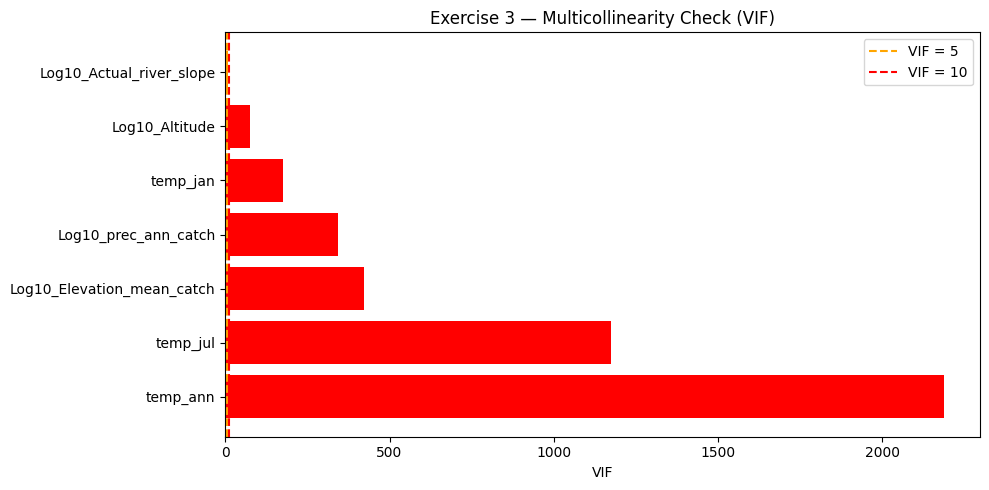


Predictors kept after VIF filter (VIF < 10): ['Log10_Actual_river_slope']

Parsimonious Model Summary:
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     751.9
Date:                Thu, 14 May 2026   Prob (F-statistic):          6.06e-154
Time:                        12:32:43   Log-Likelihood:                -11546.
No. Observations:                4819   AIC:                         2.310e+04
Df Residuals:                    4817   BIC:                         2.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [28]:
print("\n" + "="*60)
print("Multicollinearity (VIF)")
print("="*60)

# ── VIF for each predictor ────────────────────────────────────
vif_data = pd.DataFrame()
vif_data['Predictor'] = predictors
vif_data['VIF'] = [variance_inflation_factor(X_multi.values, i)
                   for i in range(len(predictors))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVariance Inflation Factor (VIF):")
print("  VIF > 10 → serious multicollinearity")
print("  VIF 5–10 → moderate multicollinearity")
print("  VIF < 5  → acceptable\n")
print(vif_data.to_string(index=False))

# ── VIF bar plot ──────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue')
          for v in vif_data['VIF']]
plt.barh(vif_data['Predictor'], vif_data['VIF'], color=colors)
plt.axvline(x=5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5')
plt.axvline(x=10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10')
plt.xlabel('VIF')
plt.title('Exercise 3 — Multicollinearity Check (VIF)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Remove high-VIF predictors and rerun ─────────────────────
# Keep only predictors with VIF < 10
keep = vif_data[vif_data['VIF'] < 10]['Predictor'].tolist()
print(f"\nPredictors kept after VIF filter (VIF < 10): {keep}")

X_pars = model_data[keep]
X_pars_sm = sm.add_constant(X_pars)
pars_model = sm.OLS(y_multi, X_pars_sm).fit()
print("\nParsimonious Model Summary:")
print(pars_model.summary())

# ── Compare full vs parsimonious coefficients ─────────────────
print("\nCoefficient comparison: Full model vs Parsimonious model:")
print(f"{'Predictor':<30} {'Full coef':>12} {'Pars coef':>12} {'Change':>10}")
print("-" * 67)
for pred in predictors:
    full_c = mlr_model.params.get(pred, np.nan)
    pars_c = pars_model.params.get(pred, np.nan)
    if not np.isnan(pars_c):
        change = pars_c - full_c
        print(f"{pred:<30} {full_c:>12.4f} {pars_c:>12.4f} {change:>10.4f}")
    else:
        print(f"{pred:<30} {full_c:>12.4f} {'removed':>12} {'—':>10}")

The VIF analysis revealed extreme multicollinearity among the predictors. All variables except Log10_Actual_river_slope had VIF values far above the critical threshold of 10. temp_ann had a VIF of 2189 and temp_jul had a VIF of 1176, which are extraordinarily high and indicate that these variables are almost perfectly correlated with each other in the model. This is ecologically logical, mean annual temperature, January temperature and July temperature are all measures of the same underlying climatic gradient and are therefore highly redundant.

After removing all variables with VIF > 10, only Log10_Actual_river_slope remained in the parsimonious model. This single-predictor model has an R² of 0.135 and remains highly significant (F=751.9, p < 0.001). Its coefficient changed from -1.55 in the full multiple model to -2.35 in the parsimonious model, becoming stronger and closer to its original simple regression value of -2.36. This stabilisation of the coefficient confirms that the inflated multicollinearity in the full model was distorting the estimates. The result show that the parsimonious model, while simpler, is more statistically reliable. Its coefficients can be trusted and interpreted meaningfully, unlike those in the full model which were heavily influenced by the correlations among predictors.